# Ahmed Abdelsalam — CatBoost Model
## Paper: *Machine Learning Approach for Predicting SLE — Oman Medical Journal 2023*
---
## Section 1: EDA & Preprocessing

In [ ]:
!pip install catboost shap -q

# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay, recall_score, precision_score, f1_score
)

# Modeling
from catboost import CatBoostClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

# Global Plot Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE   = 'Set2'
FIG_COLOR = '#f8f9fa'
TITLE_KW  = dict(fontsize=15, fontweight='bold', pad=12)

print('Libraries loaded.')


In [ ]:
# Load Dataset
file_path  = '/content/TEAM22_Master_Dataset.csv'
df         = pd.read_csv(file_path)
target_col = 'Diagnosis'

print(f'Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Target column : {target_col}')
print(f'Unique classes: {df[target_col].nunique()}')
display(df.head())


---
## 2. Data Quality & Health Check

In [ ]:
#Basic Info
print('=== Dataset Info ===')
df.info()
print()

#Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing,
                           'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('✅ No missing values found in the dataset.')
else:
    print('⚠️  Columns with missing values:')
    display(missing_df)

# Duplicates
dup_count = df.duplicated().sum()
print(f'\nDuplicate rows: {dup_count}')
df.drop_duplicates(inplace=True)
print(f'Dataset after removing duplicates: {df.shape[0]:,} rows')

#Descriptive Statistics
print('\nDescriptive Statistics')
display(df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%']))

---
## 3. Target Variable Analysis — Class Imbalance

In [ ]:
# Class Distribution
class_counts = df[target_col].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)

print('Disease Distribution')
dist_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct})
display(dist_df)

# Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=FIG_COLOR)

# Full distribution
ax1 = axes[0]
bars = ax1.bar(class_counts.index, class_counts.values,
               color=sns.color_palette(PALETTE, len(class_counts)), edgecolor='white', linewidth=0.8)
ax1.set_title('Full Disease Distribution', **TITLE_KW)
ax1.set_xlabel('Diagnosis', fontsize=12)
ax1.set_ylabel('Patient Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for bar, pct in zip(bars, class_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

# Imbalance Pie — Top 8
ax2 = axes[1]
top8 = class_counts.head(8)
other_count = class_counts.iloc[8:].sum()
pie_data = pd.concat([top8, pd.Series({'Other': other_count})])
ax2.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set3', len(pie_data)), startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Class Share — Top 8 Conditions', **TITLE_KW)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance Ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\n Imbalance ratio (majority / minority): {imbalance_ratio:.1f}x')
print('→ SMOTE or class weighting will be required during model training.')

---
## 4. Univariate Analysis — Feature Distributions

In [ ]:
#Identify Numerical Columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('Patient_ID', errors='ignore').tolist()
print(f'Numerical features ({len(num_cols)}): {num_cols}')

# Distribution + KDE for all numerical features
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), facecolor=FIG_COLOR)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax,
                 color=sns.color_palette('muted')[i % 6], edgecolor='white')
    skew_val = df[col].skew()
    ax.set_title(f'{col}\n(skew={skew_val:.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

# Hide empty subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Univariate Distributions of Clinical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

#Skewness Summary
skew_df = df[num_cols].skew().sort_values(key=abs, ascending=False)
print('\ Skewness Summary (|skew| > 1 = highly skewed)')
display(skew_df.to_frame('Skewness').style.background_gradient(cmap='RdYlGn_r'))

---
## 5. Outlier Detection — IQR Method & Z-Score
> **Addressing TA Feedback:** Deep outlier analysis across all features.

In [ ]:
# IQR-Based Outlier Detection
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

outlier_report = []
for col in num_cols:
    count, lo, hi = iqr_outliers(df[col].dropna())
    outlier_report.append({
        'Feature': col,
        'Outlier Count (IQR)': count,
        'Outlier %': round(count / len(df) * 100, 2),
        'Lower Fence': round(lo, 3),
        'Upper Fence': round(hi, 3)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('Outlier %', ascending=False)
print('Outlier Detection Report (IQR Method) ')
display(outlier_df.style.background_gradient(cmap='Oranges', subset=['Outlier %']))

In [ ]:
#Boxplots for Outlier Visualization
top_outlier_cols = outlier_df.head(8)['Feature'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor=FIG_COLOR)
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    ax = axes[i]
    sns.boxplot(y=df[col].dropna(), ax=ax,
                color=sns.color_palette('pastel')[i % 6],
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    outlier_pct = outlier_df[outlier_df['Feature']==col]['Outlier %'].values[0]
    ax.set_title(f'{col}\n({outlier_pct:.1f}% outliers)', fontsize=11, fontweight='bold')
    ax.set_ylabel('')

fig.suptitle('Outlier Detection — Top 8 Features with Most Outliers (IQR Method)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Z-Score Outlier Detection (|z| > 3)
z_outlier_report = []
for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    count = (z_scores > 3).sum()
    z_outlier_report.append({'Feature': col,
                             'Outlier Count (Z>3)': count,
                             'Outlier %': round(count / len(df) * 100, 2)})

z_df = pd.DataFrame(z_outlier_report).sort_values('Outlier %', ascending=False)
print('Z-Score Outlier Detection (|z| > 3) ')
display(z_df.style.background_gradient(cmap='Reds', subset=['Outlier %']))

print('\n Strategy: Outliers will be capped (Winsorization) during preprocessing,'
      ' not dropped, to preserve clinical data.')

---
## 6. Bivariate Analysis — Clinical Features vs. Diagnosis

In [ ]:
# Key Clinical Features vs. All Diagnoses
key_features = ['Age', 'ESR', 'CRP', 'WBC_Count']
# Filter to columns that actually exist
key_features = [f for f in key_features if f in df.columns]

# Top 5 diseases only (for readability)
top_5_diseases = df[target_col].value_counts().index[:5]
df_top5 = df[df[target_col].isin(top_5_diseases)].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor=FIG_COLOR)
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    sns.boxplot(data=df_top5, y=target_col, x=col, hue=target_col,
                palette=PALETTE, legend=False, ax=ax)
    ax.set_title(f'{col} across Top 5 Conditions', **TITLE_KW)
    ax.set_ylabel('')
    ax.set_xlabel(col, fontsize=12)

fig.suptitle('Bivariate Analysis — Key Clinical Features vs. Diagnosis (Top 5 Conditions)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bivariate_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Feature Distributions per Class — Violin & KDE Plots
> **Directly Addresses TA Feedback:** *"You should include deeper analysis (feature distributions per class)"*

In [ ]:
# Violin Plots: Feature Distribution per Diagnosis
fig, axes = plt.subplots(2, 2, figsize=(20, 14), facecolor=FIG_COLOR)
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    sns.violinplot(data=df_top5, y=target_col, x=col,
                   hue=target_col, palette=PALETTE,
                   inner='quartile', legend=False, ax=ax)
    ax.set_title(f'Distribution of {col} per Condition', **TITLE_KW)
    ax.set_ylabel('')
    ax.set_xlabel(col, fontsize=12)
    ax.axvline(df_top5[col].median(), color='red', linestyle='--',
               linewidth=1.2, label='Overall Median')
    ax.legend(fontsize=9)

fig.suptitle('Violin Plots — Feature Distribution per Condition (Quartiles Shown Inside)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('violin_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# KDE Plots: Overlapping Distributions per Class
# Shows where each class's density peaks — crucial for separability analysis

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=FIG_COLOR)
axes = axes.flatten()
palette_dict = dict(zip(top_5_diseases, sns.color_palette(PALETTE, 5)))

for i, col in enumerate(key_features):
    ax = axes[i]
    for disease in top_5_diseases:
        subset = df_top5[df_top5[target_col] == disease][col].dropna()
        sns.kdeplot(subset, ax=ax, label=disease,
                    color=palette_dict[disease], linewidth=2, fill=True, alpha=0.15)
    ax.set_title(f'KDE: {col} by Condition', **TITLE_KW)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, title='Condition')

fig.suptitle('KDE Density Plots — Class Separability Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kde_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Interpretation:')
print('  - Peaks that DON\'T overlap indicate good class separability for that feature.')
print('  - Heavily overlapping peaks suggest the feature alone is not discriminative.')

---
## 8. Correlation with Target Variable
> **Directly Addresses TA Feedback:** *"You should include correlations with target"*

In [ ]:
#Point-Biserial Correlation (numerical features vs. binary SLE target)
from scipy.stats import pointbiserialr

df['SLE_Binary'] = (df[target_col] == 'Systemic lupus erythematosus (SLE)').astype(int)

pb_corr = []
for col in num_cols:
    valid = df[[col, 'SLE_Binary']].dropna()
    corr, p = pointbiserialr(valid['SLE_Binary'], valid[col])
    pb_corr.append({'Feature': col, 'Correlation': round(corr, 4), 'p-value': round(p, 4)})

pb_df = pd.DataFrame(pb_corr).sort_values('Correlation', key=abs, ascending=False)

#  Bar Chart of Correlations
fig, ax = plt.subplots(figsize=(14, 7), facecolor=FIG_COLOR)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in pb_df['Correlation']]
bars = ax.barh(pb_df['Feature'], pb_df['Correlation'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')

# Significance markers
for j, (_, row) in enumerate(pb_df.iterrows()):
    if row['p-value'] < 0.05:
        ax.text(row['Correlation'] + (0.002 if row['Correlation'] >= 0 else -0.002),
                j, '*', va='center', fontsize=12,
                ha='left' if row['Correlation'] >= 0 else 'right', color='black')

ax.set_title('Point-Biserial Correlation: Clinical Features vs. SLE Diagnosis\n(* = statistically significant, p < 0.05)',
             **TITLE_KW)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top Predictive Features for SLE ===')
display(pb_df.head(10).style.background_gradient(cmap='RdBu_r', subset=['Correlation']))

In [ ]:
# Mutual Information Score (captures non-linear relationships)
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

df_mi = df[num_cols + ['SLE_Binary']].dropna()
X_mi  = df_mi[num_cols]
y_mi  = df_mi['SLE_Binary']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'Feature': num_cols, 'MI Score': mi_scores})\
          .sort_values('MI Score', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=FIG_COLOR)
palette_mi = sns.color_palette('viridis_r', len(mi_df))
sns.barplot(data=mi_df, x='MI Score', y='Feature', palette=palette_mi, ax=ax)
ax.set_title('Mutual Information Score — Feature Relevance to SLE Diagnosis',
             **TITLE_KW)
ax.set_xlabel('Mutual Information Score (higher = more informative)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Interpretation:')
print('  - MI Score > 0.05 indicates a potentially useful predictor.')
print('  - MI captures BOTH linear and non-linear associations (unlike correlation).')

---
## 9. Multivariate Analysis — Correlation & Multicollinearity

In [ ]:
#  Correlation Heatmap
corr_matrix = df[num_cols].corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14), facecolor=FIG_COLOR)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', **TITLE_KW)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#  Identify Highly Correlated Pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, round(upper_tri.loc[row, col], 3))
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if abs(upper_tri.loc[row, col]) > 0.8]

high_corr = list(set([col for col, _, _ in high_corr_pairs]))

print('\n Highly Correlated Feature Pairs (|r| > 0.80)')
if high_corr_pairs:
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {f1:25s} ↔ {f2:25s}  r = {r}')
    print(f'\n→ Consider dropping: {high_corr}')
else:
    print('  No pairs exceed the 0.80 threshold.')

In [ ]:
#  Pairplot: Top 4 Features by MI Score
top4_features = mi_df.head(4)['Feature'].tolist()
print(f'Creating pairplot for top MI features: {top4_features}')

pair_df = df_top5[top4_features + [target_col]].dropna()
g = sns.pairplot(pair_df, hue=target_col, palette=PALETTE,
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20},
                 diag_kws={'fill': True, 'alpha': 0.4})
g.fig.suptitle('Pairplot — Top 4 Most Informative Features by Mutual Information\n(Top 5 Conditions)',
               y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Categorical Analysis

In [ ]:
#  Categorical Columns
cat_cols = df.select_dtypes(include='object').columns.drop(target_col, errors='ignore').tolist()
print(f'Categorical features: {cat_cols}')

# Create SLE_Label (string version of SLE_Binary) for grouping/labeling
if 'SLE_Binary' in df.columns:
    df['SLE_Label'] = df['SLE_Binary'].map({1: 'SLE', 0: 'Non-SLE'})
else:
    df['SLE_Label'] = df[target_col].apply(
        lambda x: 'SLE' if x == 'Systemic lupus erythematosus (SLE)' else 'Non-SLE'
    )

#Gender Distribution
if 'Gender' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=FIG_COLOR)

    # Overall gender distribution
    gender_counts = df['Gender'].value_counts()
    axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                colors=['#3498db', '#e74c3c', '#2ecc71'],
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[0].set_title('Overall Gender Distribution', **TITLE_KW)

    # Gender vs. SLE
    gender_sle = df.groupby(['Gender', 'SLE_Label']).size().unstack(fill_value=0)
    gender_sle_pct = gender_sle.div(gender_sle.sum(axis=1), axis=0) * 100
    gender_sle_pct.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'],
                        edgecolor='white', rot=0)
    axes[1].set_title('Gender vs. SLE Diagnosis (%)', **TITLE_KW)
    axes[1].set_xlabel('Gender', fontsize=12)
    axes[1].set_ylabel('Percentage (%)', fontsize=12)
    axes[1].legend(title='Diagnosis')

    plt.tight_layout()
    plt.savefig('gender_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Chi-square test: Gender vs. SLE
    from scipy.stats import chi2_contingency
    contingency = pd.crosstab(df['Gender'], df['SLE_Label'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f'\nChi-Square Test: Gender vs. SLE')
    print(f'  \u03c7\u00b2 = {chi2:.4f},  p-value = {p:.4e},  dof = {dof}')
    if p < 0.05:
        print('  Significant association \u2014 Gender is a relevant feature.')
    else:
        print(' No significant association found.')


---
## Section 2: Paper Implementation
### Paper: *Machine Learning Approach for Predicting SLE in an Oman-Based Cohort*
### Oman Medical Journal (Sultan Qaboos University), 2023
**Method:** Binary classification (SLE vs Non-SLE) using RFE feature selection + CatBoost + SHAP interpretability

**Paper results:** AUC = 0.95, Sensitivity = 92%

### Step 1 — Find SLE Label & Create Binary Target

In [70]:
# Standardize all lupus-related labels into one single 'SLE' label
lupus_names = [
    'Systemic lupus erythematosus (SLE)',
    'Systemic Lupus Erythematosus',
    'Lupus nephritis',
    'Lupus vasculitis'
]
df['Diagnosis'] = df['Diagnosis'].replace(lupus_names, 'SLE')

# Create binary target: SLE=1, everything else=0
df['SLE_Target'] = (df['Diagnosis'] == 'SLE').astype(int)

print('Binary target distribution:')
print(df['SLE_Target'].value_counts())
print(f'\nSLE prevalence: {df["SLE_Target"].mean()*100:.1f}%')

Binary target distribution:
SLE_Target
0    39934
1     5271
Name: count, dtype: int64

SLE prevalence: 11.7%


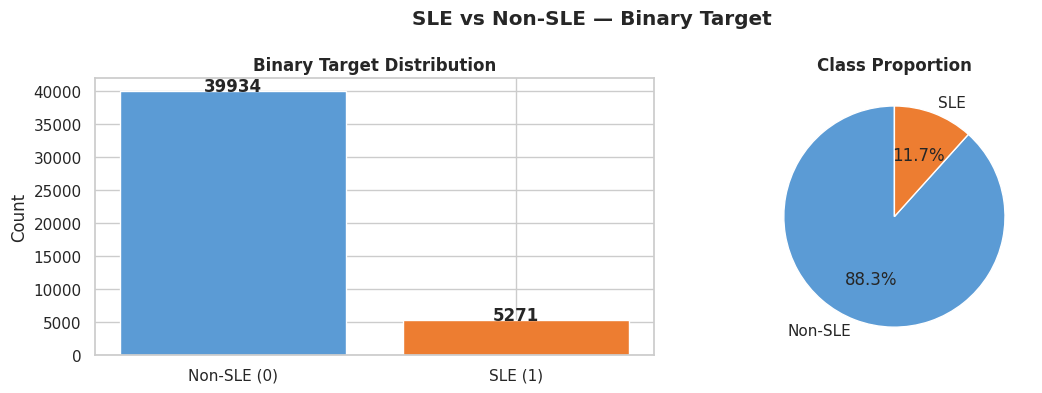

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['SLE_Target'].value_counts()
axes[0].bar(['Non-SLE (0)', 'SLE (1)'], counts.values, color=['#5B9BD5', '#ED7D31'])
axes[0].set_title('Binary Target Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Non-SLE', 'SLE'], autopct='%1.1f%%',
            colors=['#5B9BD5', '#ED7D31'], startangle=90)
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('SLE vs Non-SLE — Binary Target', fontweight='bold')
plt.tight_layout()
plt.show()

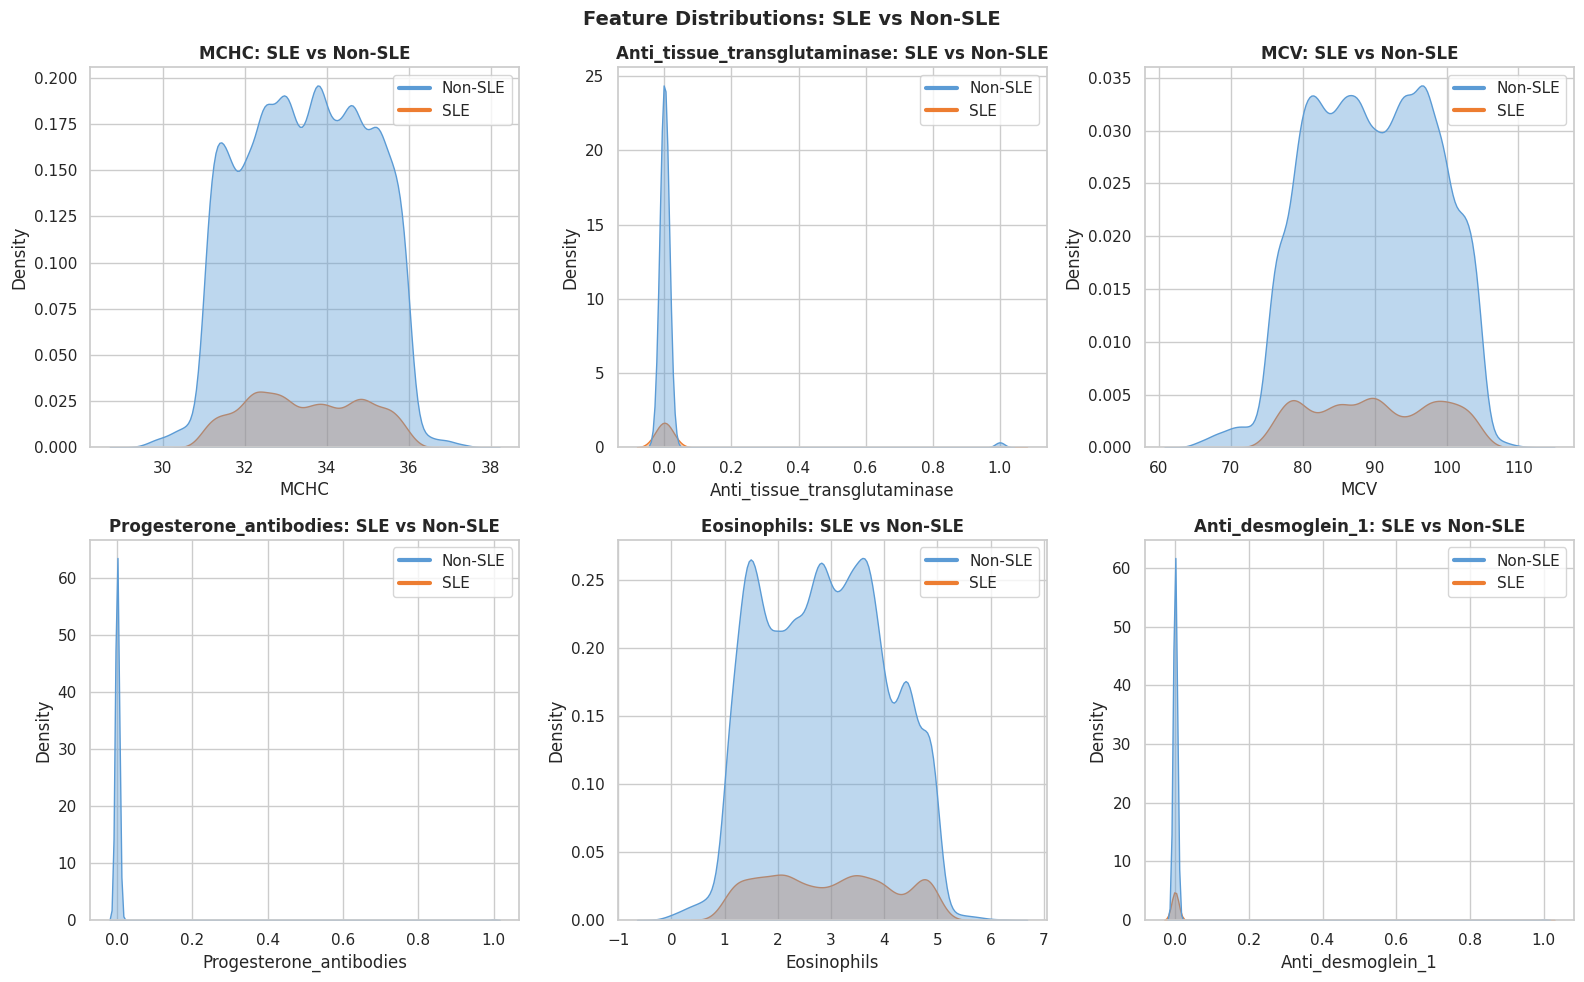

In [72]:
num_features = [c for c in df.select_dtypes(include=['float64','int64']).columns
                if c not in ['SLE_Target', 'Patient_ID']]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features[:6]):
    sns.kdeplot(data=df, x=feat, hue='SLE_Target', ax=axes[i],
                palette={0: '#5B9BD5', 1: '#ED7D31'}, fill=True, alpha=0.4)
    axes[i].set_title(f'{feat}: SLE vs Non-SLE', fontweight='bold')
    handles = [plt.Line2D([0],[0], color='#5B9BD5', lw=3),
               plt.Line2D([0],[0], color='#ED7D31', lw=3)]
    axes[i].legend(handles, ['Non-SLE', 'SLE'])

plt.suptitle('Feature Distributions: SLE vs Non-SLE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

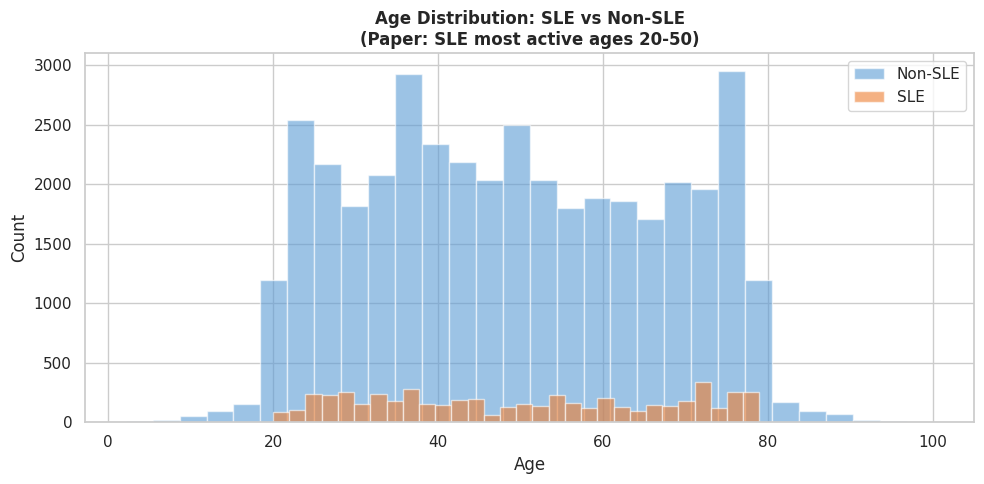

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))
df[df['SLE_Target'] == 0]['Age'].hist(bins=30, alpha=0.6, label='Non-SLE', color='#5B9BD5', ax=ax)
df[df['SLE_Target'] == 1]['Age'].hist(bins=30, alpha=0.6, label='SLE', color='#ED7D31', ax=ax)
ax.set_title('Age Distribution: SLE vs Non-SLE\n(Paper: SLE most active ages 20-50)', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

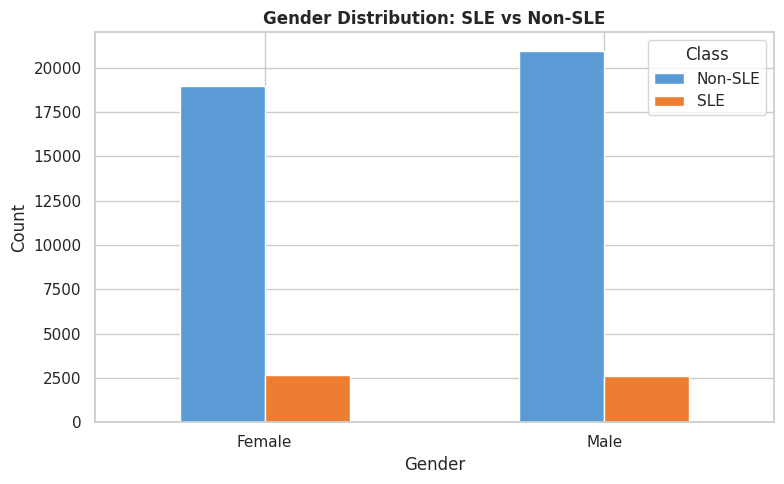

In [74]:
if 'Gender' in df.columns:
    sle_gender = df.groupby(['Gender', 'SLE_Target']).size().unstack(fill_value=0)
    sle_gender.columns = ['Non-SLE', 'SLE']
    sle_gender.plot(kind='bar', figsize=(8, 5), color=['#5B9BD5', '#ED7D31'], edgecolor='white')
    plt.title('Gender Distribution: SLE vs Non-SLE', fontweight='bold')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

In [75]:
df_model = df.copy()
df_model.drop(columns=['Patient_ID', 'Research_Target'], errors='ignore', inplace=True)

for col in df_model.select_dtypes(include='number').columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

cat_cols = [c for c in df_model.select_dtypes(include='object').columns
            if c != 'Diagnosis']
le_enc = LabelEncoder()
for col in cat_cols:
    df_model[col] = le_enc.fit_transform(df_model[col].astype(str))

print(f"Missing values remaining: {df_model.isnull().sum().sum()}")
print(f"Shape: {df_model.shape}")

Missing values remaining: 0
Shape: (45205, 79)


In [76]:
X = df_model.drop(columns=['Diagnosis', 'SLE_Target', 'Research_Target'], errors='ignore')
y = df_model['SLE_Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | SLE rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}  | SLE rate: {y_test.mean():.2%}")
print(f"Columns in X: {X.columns.tolist()}")

Train: (36164, 77) | SLE rate: 11.66%
Test:  (9041, 77)  | SLE rate: 11.66%
Columns in X: ['MCHC', 'Anti_tissue_transglutaminase', 'MCV', 'Progesterone_antibodies', 'Eosinophils', 'Anti_desmoglein_1', 'Weight loss', 'Anti_parietal_cell', 'C3', 'Hematocrit', 'pANCA', 'Rheumatoid factor', 'Joint pain', 'Anti-Tg', 'RBC_Count', 'IgG_IgE_receptor', 'Fatigue or chronic tiredness', 'Anti_BP180', 'Lymphocytes', 'Anti-SMA', 'Anti_Sm', 'Anti_OmpC', 'Esbach', 'WBC_Count', 'Anti_type_VII_collagen', 'Anti_Jo1', 'Anti_TIF1', 'Anti_La_SSB', 'MCH', 'anti_centromere', 'anti_LKM1', 'CRP', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_tTG', 'Anti_desmoglein_3', 'C4', 'ASCA', 'Anti_RNP', 'Anti_dsDNA', 'Anti_enterocyte_antibodies', 'Low-grade fever', "General 'unwell' feeling", 'PLT_Count', 'Monocytes', 'Anti_Mi2', 'Sickness_Duration_Months', 'Rashes and skin lesions', 'Anti_epidermal_basement_membrane_IgA', 'Anti_IF', 'Neutrophils', 'Hemoglobin', 'ANCA', 'MBL_Level', 'ASMA', 'Reticulocyte_Count', 'RDW', 'Age', 'Anti-S

In [77]:
n_features_to_select = min(10, X_train.shape[1])

rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    n_features_to_select=n_features_to_select,
    step=1
)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_].tolist()
print(f"Selected {len(selected_features)} features:")
for f in selected_features:
    print(f"  - {f}")

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

Selected 10 features:
  - MCV
  - Eosinophils
  - Hematocrit
  - Lymphocytes
  - Esbach
  - WBC_Count
  - Monocytes
  - Neutrophils
  - Hemoglobin
  - Reticulocyte_Count


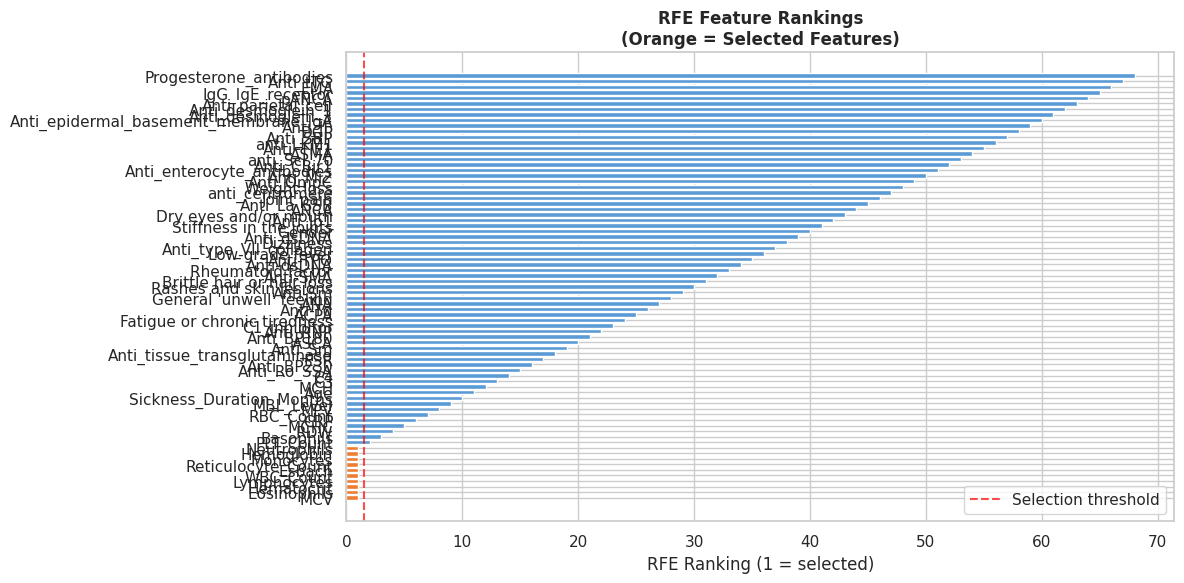

In [78]:
rfe_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

plt.figure(figsize=(12, 6))
bar_colors = ['#ED7D31' if r == 1 else '#5B9BD5' for r in rfe_df['Ranking']]
plt.barh(rfe_df['Feature'], rfe_df['Ranking'], color=bar_colors)
plt.xlabel('RFE Ranking (1 = selected)')
plt.title('RFE Feature Rankings\n(Orange = Selected Features)', fontweight='bold')
plt.axvline(x=1.5, color='red', linestyle='--', alpha=0.7, label='Selection threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print(f"Class weights: {class_weights_dict}")

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    class_weights=[class_weights_dict[0], class_weights_dict[1]]
)

catboost_model.fit(
    X_train_sel, y_train,
    eval_set=(X_test_sel, y_test),
    plot=False
)
print('Training complete.')

Class weights: {np.int64(0): np.float64(0.5659999373963126), np.int64(1): np.float64(4.287882380839459)}
0:	test: 0.7941318	best: 0.7941318 (0)	total: 45ms	remaining: 22.5s
100:	test: 0.9587638	best: 0.9587638 (100)	total: 1.91s	remaining: 7.53s
200:	test: 0.9767358	best: 0.9767358 (200)	total: 5.47s	remaining: 8.14s
300:	test: 0.9815333	best: 0.9815333 (300)	total: 9.42s	remaining: 6.23s
400:	test: 0.9834623	best: 0.9835063 (397)	total: 14.7s	remaining: 3.62s
499:	test: 0.9842416	best: 0.9843094 (487)	total: 18.7s	remaining: 0us

bestTest = 0.9843094174
bestIteration = 487

Shrink model to first 488 iterations.
Training complete.


In [80]:
y_prob_full = catboost_model.predict_proba(X_test_sel)
y_prob = y_prob_full[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

acc       = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print(f'Threshold used: {threshold}')
print('=' * 50)
print(f'  Accuracy : {acc:.4f}')
print(f'  AUC      : {auc_score:.4f}  (Paper: 0.95)')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Non-SLE', 'SLE']))
print(f'SLE predictions: {y_pred.sum()} out of {len(y_pred)}')

Threshold used: 0.3
  Accuracy : 0.9646
  AUC      : 0.9843  (Paper: 0.95)
              precision    recall  f1-score   support

     Non-SLE       0.99      0.97      0.98      7987
         SLE       0.78      0.96      0.86      1054

    accuracy                           0.96      9041
   macro avg       0.89      0.96      0.92      9041
weighted avg       0.97      0.96      0.97      9041

SLE predictions: 1292 out of 9041


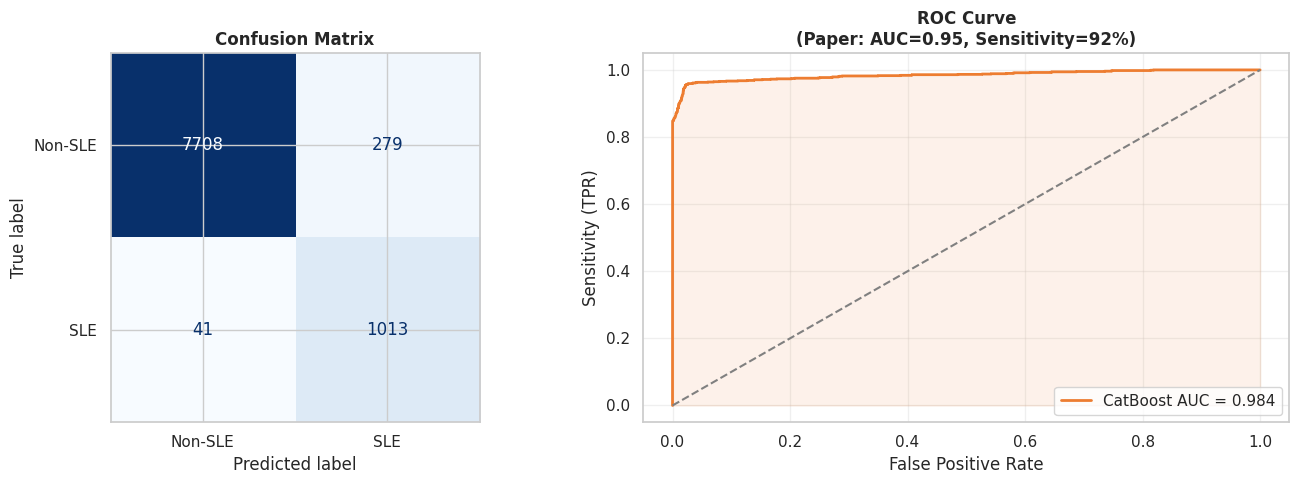

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-SLE', 'SLE']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#ED7D31', lw=2, label=f'CatBoost AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'gray', linestyle='--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#ED7D31')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('Sensitivity (TPR)')
axes[1].set_title('ROC Curve\n(Paper: AUC=0.95, Sensitivity=92%)', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
cv_model = CatBoostClassifier(
    iterations=300, learning_rate=0.05,
    depth=6, random_seed=42, verbose=0
)
cv_scores = cross_val_score(
    cv_model, X[selected_features], y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'5-Fold CV AUC : {cv_scores.round(4)}')
print(f'Mean +/- Std  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-Fold CV AUC : [0.9685 0.9641 0.9672 0.9725 0.9662]
Mean +/- Std  : 0.9677 +/- 0.0028


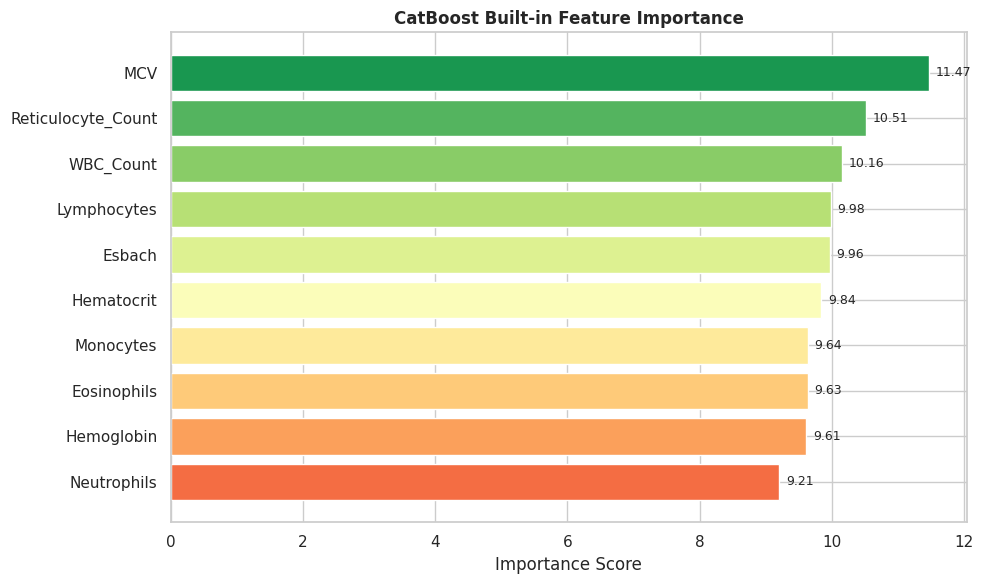

In [83]:
feat_imp = pd.Series(
    catboost_model.get_feature_importance(),
    index=selected_features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
imp_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
bars = plt.barh(feat_imp.index, feat_imp.values, color=imp_colors, edgecolor='white')
plt.xlabel('Importance Score')
plt.title('CatBoost Built-in Feature Importance', fontweight='bold')
for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [84]:
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test_sel)
print(f'SHAP values shape: {np.array(shap_values).shape}')
print('SHAP values computed.')

SHAP values shape: (9041, 10)
SHAP values computed.


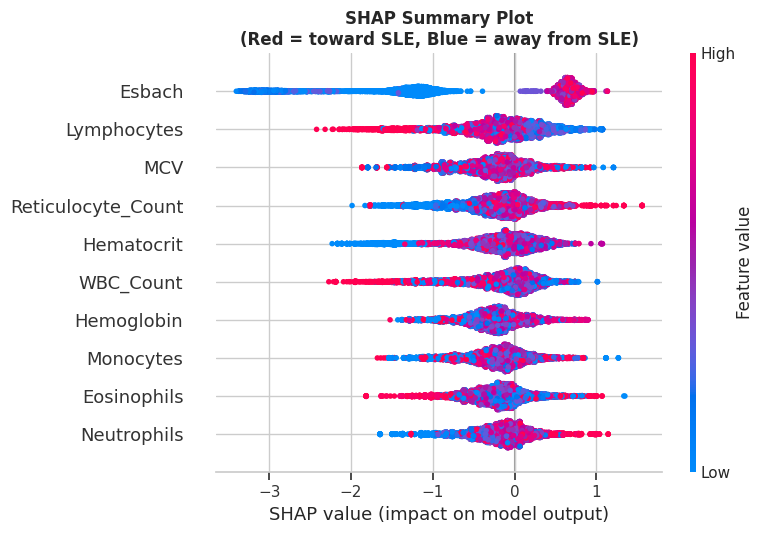

In [85]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type='dot', show=False)
plt.title('SHAP Summary Plot\n(Red = toward SLE, Blue = away from SLE)', fontweight='bold')
plt.tight_layout()
plt.show()

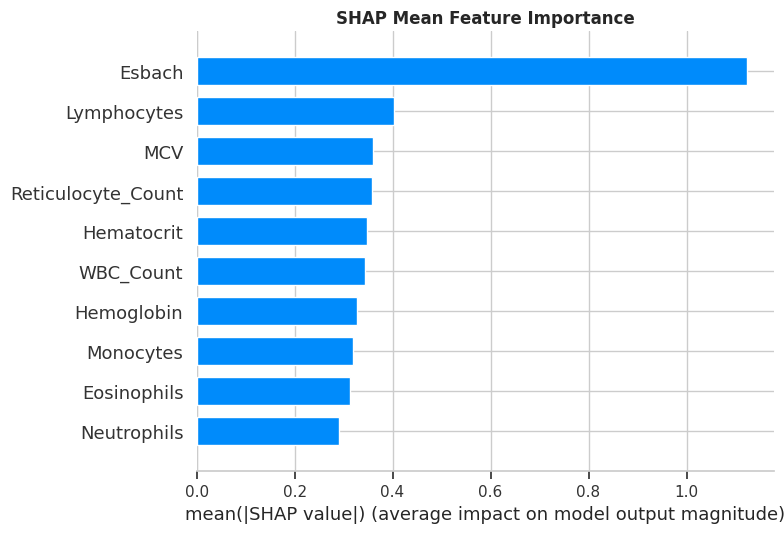

In [86]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type='bar', show=False)
plt.title('SHAP Mean Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

Patient #6 | SLE prob: 0.9369 | Actual: 1


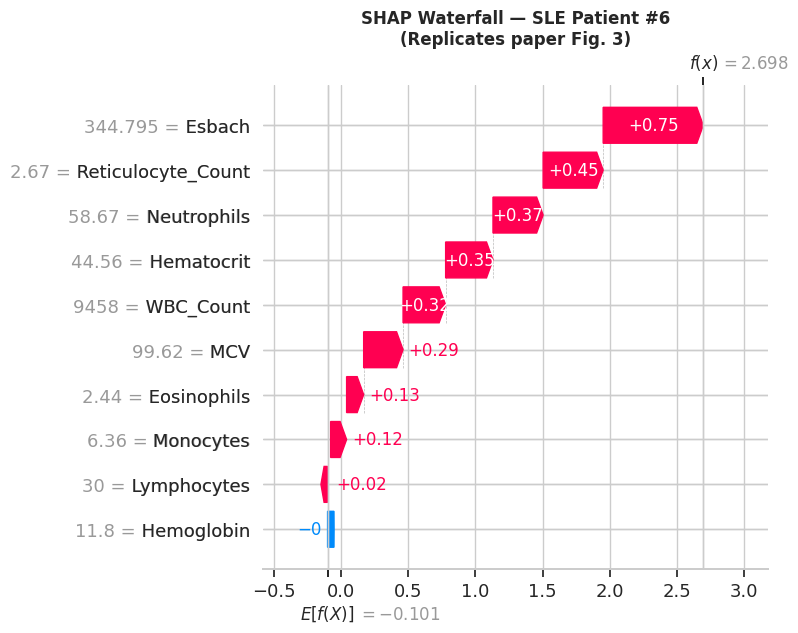

In [87]:
sle_indices = np.where((np.array(y_pred) == 1) & (y_test.values == 1))[0]

if len(sle_indices) == 0:
    print("No true positives found — using highest SLE probability patient")
    patient_idx = int(np.argmax(y_prob))
else:
    patient_idx = sle_indices[0]

print(f'Patient #{patient_idx} | SLE prob: {y_prob[patient_idx]:.4f} | Actual: {y_test.values[patient_idx]}')

explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_test_sel.iloc[patient_idx].values,
    feature_names=selected_features
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP Waterfall — SLE Patient #{patient_idx}\n(Replicates paper Fig. 3)', fontweight='bold')
plt.tight_layout()
plt.show()

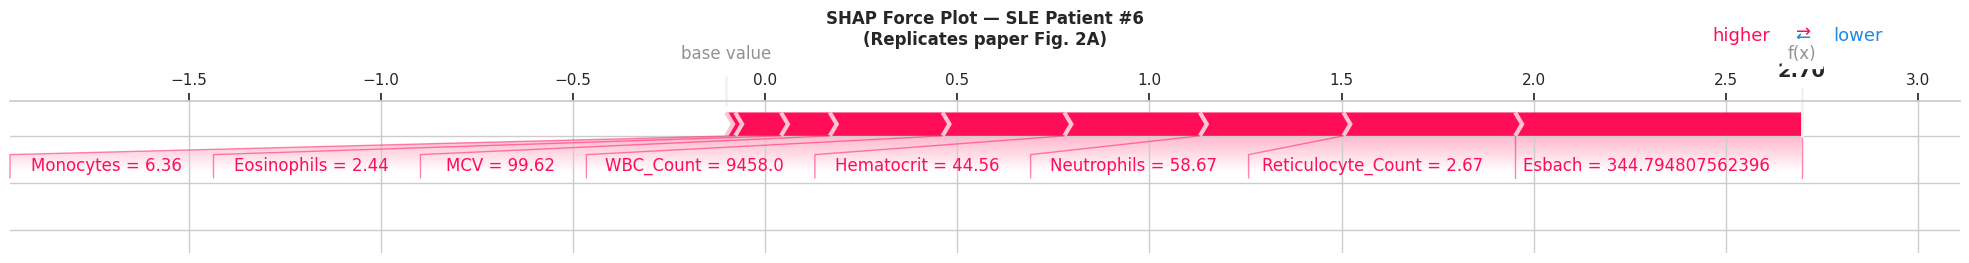

In [88]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[patient_idx],
    X_test_sel.iloc[patient_idx],
    feature_names=selected_features,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — SLE Patient #{patient_idx}\n(Replicates paper Fig. 2A)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Patient #0 | SLE prob: 0.0072 | Actual: 0


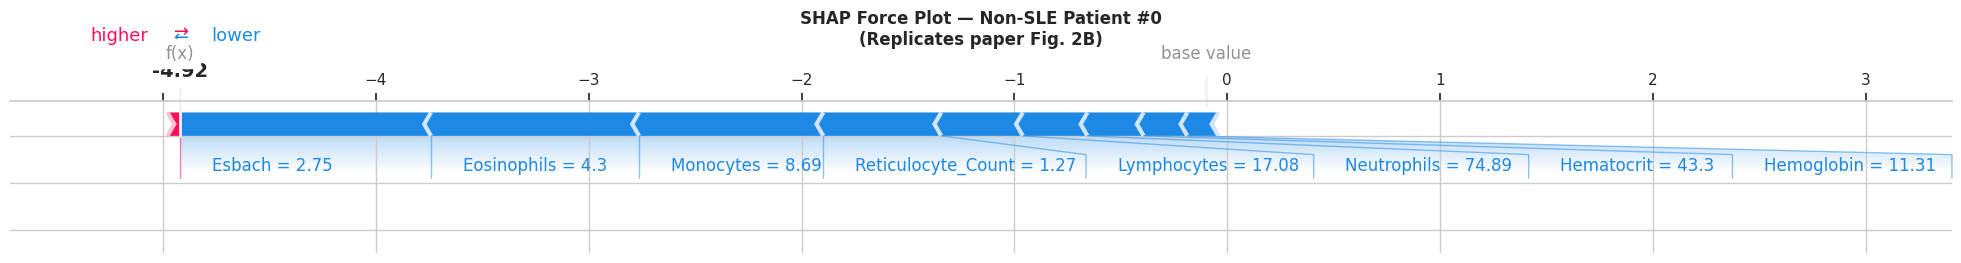

In [89]:
non_sle_indices = np.where((np.array(y_pred) == 0) & (y_test.values == 0))[0]
p2_idx = non_sle_indices[0] if len(non_sle_indices) > 0 else int(np.argmin(y_prob))

print(f'Patient #{p2_idx} | SLE prob: {y_prob[p2_idx]:.4f} | Actual: {y_test.values[p2_idx]}')

shap.force_plot(
    explainer.expected_value,
    shap_values[p2_idx],
    X_test_sel.iloc[p2_idx],
    feature_names=selected_features,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Non-SLE Patient #{p2_idx}\n(Replicates paper Fig. 2B)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [90]:
sensitivity = recall_score(y_test, y_pred, pos_label=1)
specificity = recall_score(y_test, y_pred, pos_label=0)
precision   = precision_score(y_test, y_pred, pos_label=1)
f1          = f1_score(y_test, y_pred, pos_label=1)

print('=' * 55)
print('     AHMED ABDELSALAM — CATBOOST RESULTS SUMMARY')
print('=' * 55)
print(f'  Accuracy    : {acc:.4f}')
print(f'  AUC (ROC)   : {auc_score:.4f}   | Paper target: 0.95')
print(f'  Sensitivity : {sensitivity:.4f}   | Paper target: 0.92')
print(f'  Specificity : {specificity:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'  F1 Score    : {f1:.4f}')
print(f'  Threshold   : {threshold}')
print(f'  CV AUC      : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('=' * 55)
print(f'  RFE selected features ({len(selected_features)}):')
for f in selected_features:
    print(f'    - {f}')
print('=' * 55)

     AHMED ABDELSALAM — CATBOOST RESULTS SUMMARY
  Accuracy    : 0.9646
  AUC (ROC)   : 0.9843   | Paper target: 0.95
  Sensitivity : 0.9611   | Paper target: 0.92
  Specificity : 0.9651
  Precision   : 0.7841
  F1 Score    : 0.8636
  Threshold   : 0.3
  CV AUC      : 0.9677 +/- 0.0028
  RFE selected features (10):
    - MCV
    - Eosinophils
    - Hematocrit
    - Lymphocytes
    - Esbach
    - WBC_Count
    - Monocytes
    - Neutrophils
    - Hemoglobin
    - Reticulocyte_Count
